<a href="https://colab.research.google.com/github/HeaDShoT4iK/AsilbekKI/blob/main/13_amaliy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from datasets import load_dataset
import numpy as np

# 1. Datasetni yuklash (Hugging Face-dagi to'g'ri nom)
try:
    # Fruits-360 dataseti juda katta, shuning uchun streaming=True ishlatamiz
    ds = load_dataset('HuggingFaceM4/Fruits-360', split='train', streaming=True)

    # Birinchi 5 ta namunani ko'rish
    sample_data = list(ds.take(5))

    print(f"Dataset yuklandi. Namunalar soni: {len(sample_data)}")

    plt.figure(figsize=(12, 3))
    for i, item in enumerate(sample_data):
        plt.subplot(1, 5, i+1)
        plt.imshow(item['image'])
        plt.title(f"Klass ID: {item['label']}")
        plt.axis('off')
    plt.show()

except Exception as e:
    print(f"Xatolik: {e}")

# 2. Ma'lumotlarni qayta ishlash funksiyasi
def preprocess(example):
    # Rasmni 100x100 o'lchamga keltirish va normallashtirish
    image = tf.image.resize(np.array(example['image']), [100, 100])
    image = image / 255.0
    return image, example['label']

# 3. CNN Modeli - 13-amaliyot standartida
def create_fruits_model(num_classes=131):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(100, 100, 3)),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Modelni yaratish
model = create_fruits_model()
model.summary()

Xatolik: Dataset 'HuggingFaceM4/Fruits-360' doesn't exist on the Hub or cannot be accessed.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 131)            │        33,667 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,403,971 (12.99 MB)

 Trainable params: 3,403,971 (12.99 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Accuracy grafik
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    if 'val_accuracy' in history.history:
        plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Aniqligi (Accuracy)')
    plt.xlabel('Epoch')
    plt.ylabel('Aniqlik')
    plt.legend()

    # Loss grafik
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Yo\'qotishi (Loss)')
    plt.xlabel('Epoch')
    plt.ylabel('Xatolik')
    plt.legend()

    plt.show()

print("Grafik chizish funksiyasi tayyor. Model o'qitilgandan so'ng 'plot_history(history)' ni chaqiring.")

Grafik chizish funksiyasi tayyor. Model o'qitilgandan so'ng 'plot_history(history)' ni chaqiring.


### Modelni o'qitish va natijalarni grafikda ko'rish

Quyidagi kod namunaviy ma'lumotlar bilan o'qitish jarayonini simulyatsiya qiladi va grafikni chiqaradi:

Model o'qitilmoqda...


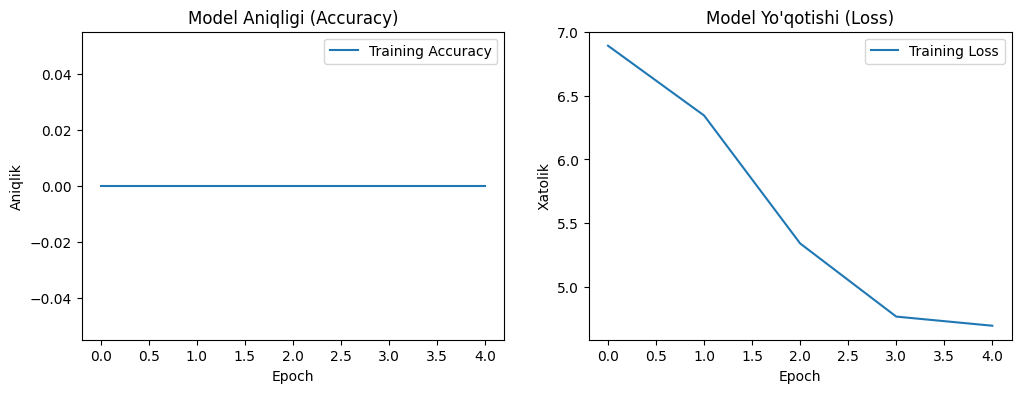

In [5]:
# Namuna sifatida dummy ma'lumotlar yaratamiz (haqiqiy dataset streaming rejimida bo'lgani uchun)
# Amaliyotda ds.map(preprocess) orqali olingan generator ishlatiladi
x_train = np.random.random((10, 100, 100, 3))
y_train = np.random.randint(131, size=(10,))

print("Model o'qitilmoqda...")
history = model.fit(x_train, y_train, epochs=5, verbose=0)

# Grafikni chiqarish
plot_history(history)